In [150]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk

In [151]:
choice = 4  #start from 0
devices = ['nmos4', 'pmos4','nmos_xh018','pmos_xh018', 'nmos_T40N', 'pmos_T40N']
fet = lk('../lookup_table/040/'+devices[choice]+'.mat')

In [152]:
# sweep variable vectors
l = fet['L']
vgs = fet['VGS']
vds = fet['VDS']
vsb = fet['VSB']

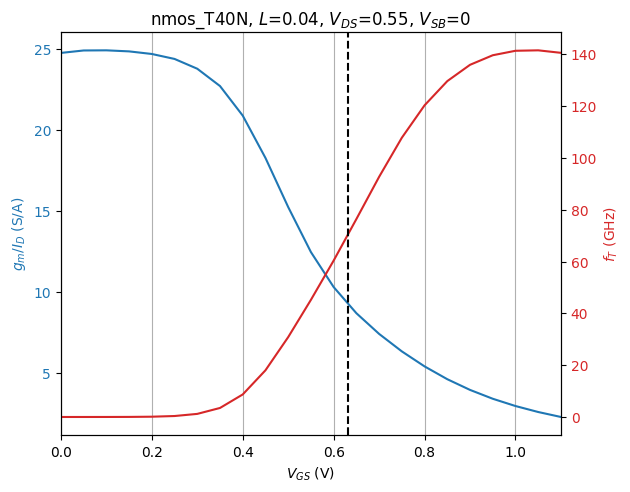

In [153]:
# plot gm/ID and fT versus gate bias
L1 = min(l); VDS1=vds[-1]/2; VSB1=0
VGS = vgs
gm_id1 = fet.lookup('GM_ID', L=L1, VDS=VDS1, VSB=VSB1, VGS = VGS)
ft1 = fet.lookup('GM_CGG', L=L1, VDS=VDS1, VSB=VSB1, VGS = VGS)/2/np.pi
vt = fet.lookup('VT', L=L1, VGS=0.9, VDS=VDS1, VSB=VSB1)

fig, ax1 = plt.subplots()
ax1.grid(axis='x')
ax1.set_xlabel('$V_{GS}$ (V)')
color = 'tab:blue'
ax1.set_ylabel('$g_m/I_D$ (S/A)', color=color)
ax1.plot(vgs, gm_id1, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('$f_T$ (GHz)', color=color)
ax2.plot(vgs, ft1/1e9, color=color)
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.xlim(0, vgs[-1])
plt.axvline(x=vt, color='k', linestyle='--')
plt.show()

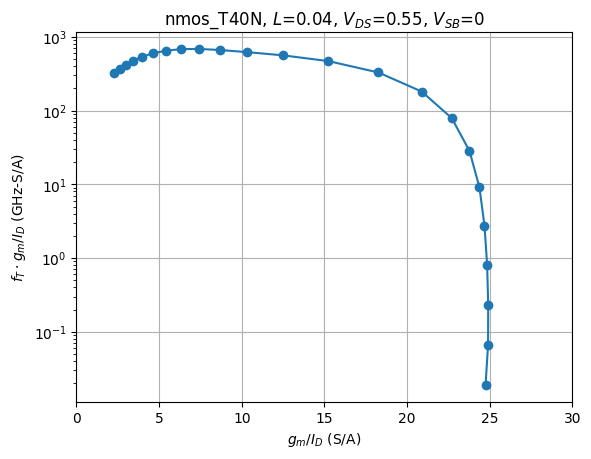

In [154]:
# plot product of gm/ID ant fT versus gm/ID
plt.semilogy(gm_id1, gm_id1*ft1/1e9,marker='o')
plt.xlim(0, 30)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'$f_T\cdot g_m/I_D$ (GHz-S/A)')
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

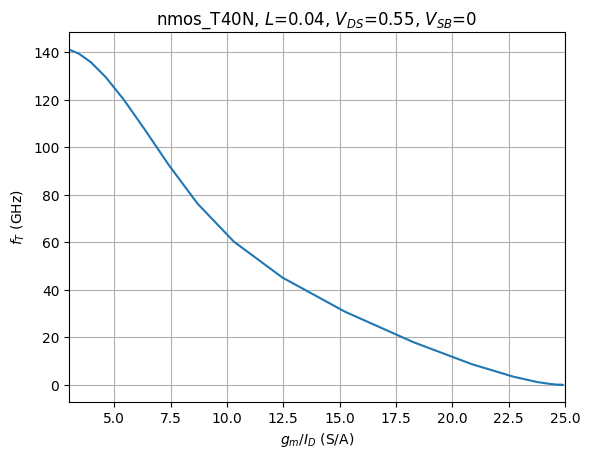

In [155]:
# plot fT versus gm/ID
plt.plot(gm_id1, ft1/1e9)
plt.xlim(3, 25)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('$f_T$ (GHz)')
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

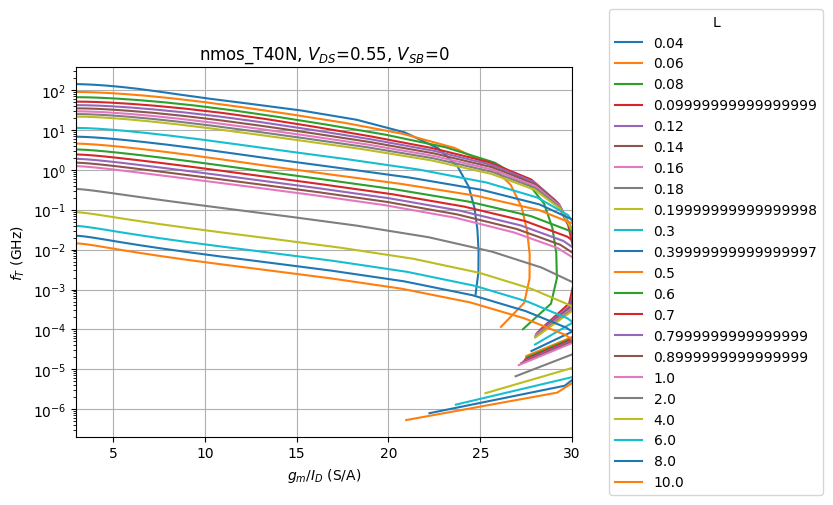

In [156]:
# plot fT versus gm/ID for all L
VDS2=vds[-1]/2; VSB2=0
gm_id2 = fet.lookup('GM_ID', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)
ft2 = fet.lookup('GM_CGG', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)/2/np.pi

fig, ax = plt.subplots()
ax.semilogy(gm_id2.transpose(), ft2.transpose()/1e9)
ax.legend(loc='center right', bbox_to_anchor=(1.52, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 30)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'$f_T$ (GHz)')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

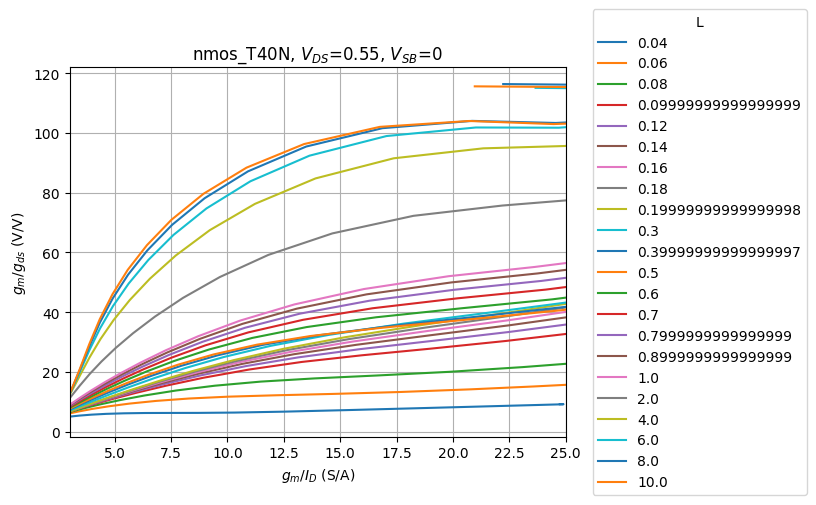

In [157]:
# plot gm/gds versus gm/ID for all L
gm_gds2 = fet.lookup('GM_GDS', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)

fig, ax = plt.subplots()
ax.plot(gm_id2.transpose(), gm_gds2.transpose())
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 25)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'$g_m/g_{ds}$ (V/V)')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.grid()
plt.show()

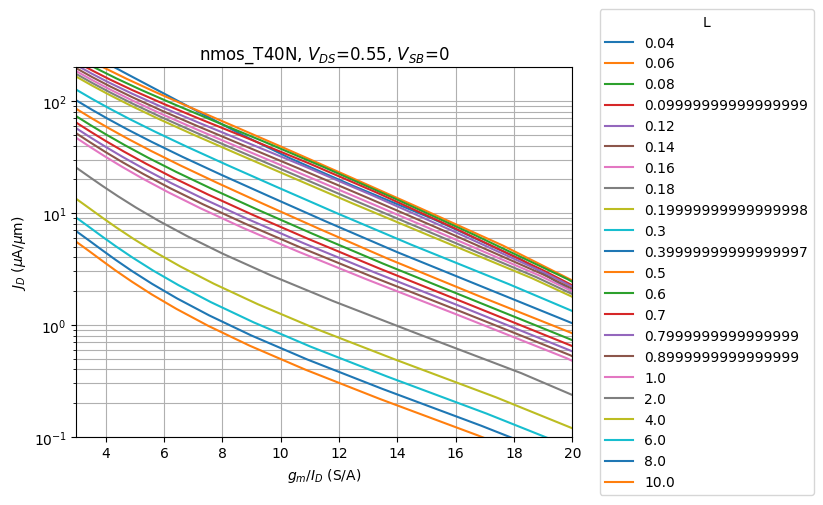

In [158]:
# plot jd versus gm/ID for all L
jd2 = fet.lookup('ID_W', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)/1e-6

fig, ax = plt.subplots()
ax.semilogy(gm_id2.transpose(), jd2.transpose())
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0.1, 200)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'$J_D$ ($\mu$A/$\mu$m)')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()

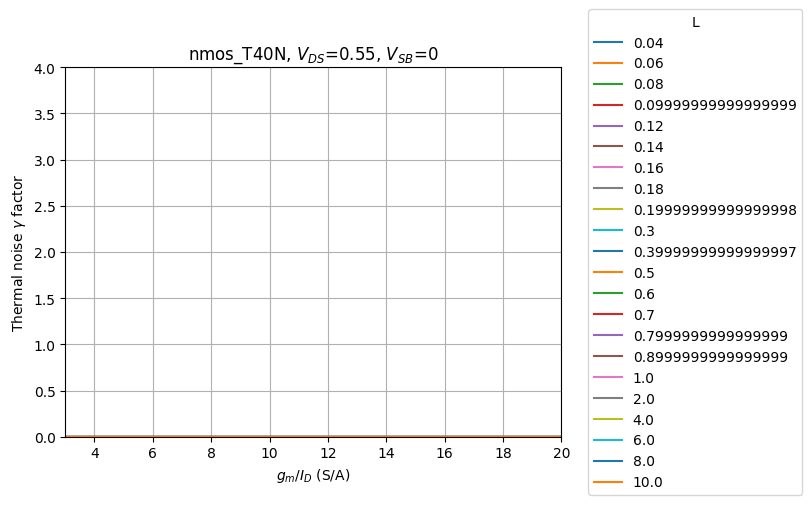

[[1.21592664e-32 4.23338566e-32 1.47196765e-31 5.09872226e-31
  1.75370515e-30 5.93744503e-30 1.95353277e-29 6.12628409e-29
  1.77713732e-28 4.63552287e-28 1.06733095e-27 2.13384544e-27
  3.65735320e-27 5.40608112e-27 7.08826696e-27 8.55058882e-27
  9.83904361e-27 1.11326212e-26 1.26292758e-26 1.45738827e-26
  1.72230857e-26 2.09592840e-26 2.63073981e-26]
 [9.73623789e-36 6.10037237e-34 2.45139331e-33 9.81503536e-33
  3.91282639e-32 1.54121431e-31 5.94525377e-31 2.20186354e-30
  7.60919869e-30 2.37332353e-29 6.45103651e-29 1.48819341e-28
  2.93268760e-28 5.08909123e-28 8.08550372e-28 1.21394647e-27
  1.75800909e-27 2.49804379e-27 3.50745568e-27 4.91630201e-27
  6.90011508e-27 9.75188169e-27 1.39265435e-26]
 [1.47286699e-36 1.19916559e-34 5.62940758e-34 2.43261465e-33
  1.04241792e-32 4.41087689e-32 1.81369179e-31 7.07978766e-31
  2.52341796e-30 7.91036768e-30 2.13402949e-29 5.01386030e-29
  1.05810087e-28 2.05693270e-28 3.75254285e-28 6.48155090e-28
  1.07183936e-27 1.71096490e-27 2.65

In [159]:
# plot gamma versus gm/ID for all L
gamma = fet.lookup('STH_GM', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS) / (4*sc.Boltzmann*300)
fig, ax = plt.subplots()
ax.plot(gm_id2.transpose(), gamma.transpose())
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0, 4)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'Thermal noise $\gamma$ factor')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()

print(gamma)

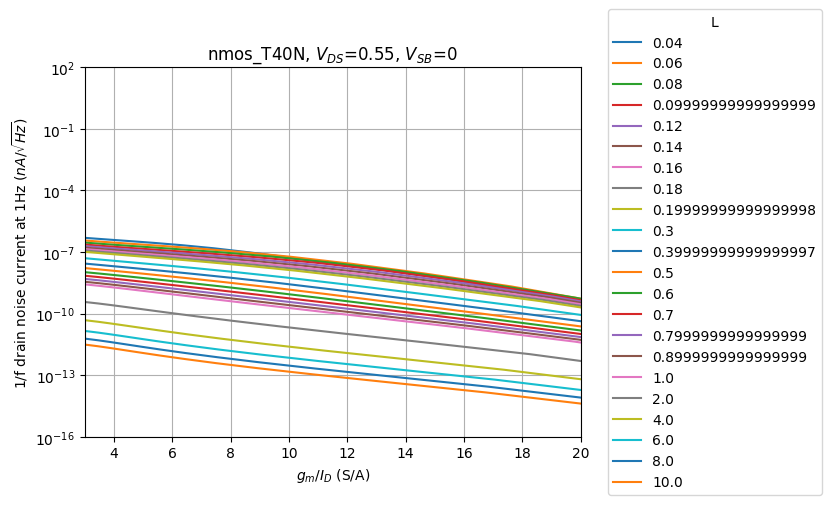

In [160]:
# plot flicker noise drain current at 1Hz versus gm/ID for all L
sfl = fet.lookup('SFL', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)**0.5

fig, ax = plt.subplots()
ax.semilogy(gm_id2.transpose(), sfl.transpose()/1e-9)
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0.0000000000000001, 100)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'1/f drain noise current at 1Hz ($nA/ \sqrt{Hz}$)')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()

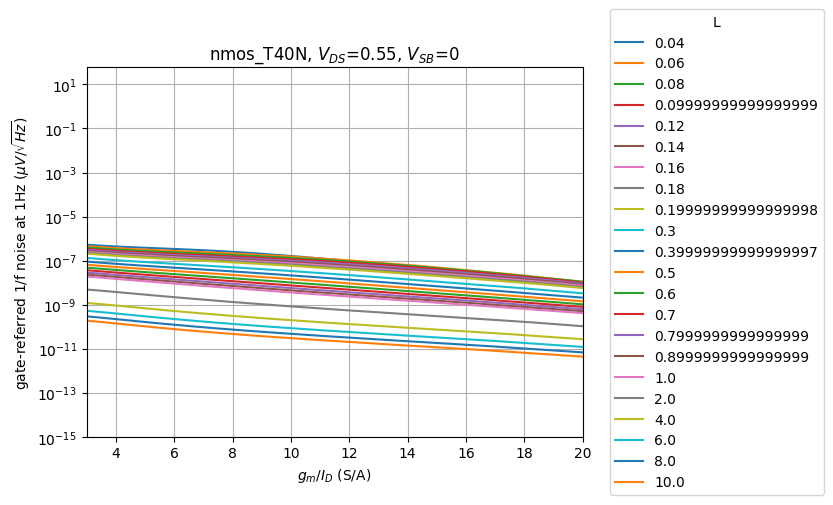

In [161]:
# plot gate-referred 1/f noise at 1Hz versus gm/ID for all L
sfl_gate = fet.lookup('SFL', L=l, VDS=VDS1, VSB=VSB1, VGS=VGS)**0.5 / fet.lookup('GM', L=l, VDS=VDS1, VSB=VSB1)

fig, ax = plt.subplots()
ax.semilogy(gm_id2.transpose(), sfl_gate.transpose()/1e-6)
ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0.000000000000001, 60)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'gate-referred 1/f noise at 1Hz ($\mu V/ \sqrt{Hz}$)')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()